<a href="https://colab.research.google.com/github/SuyashPatil-max/CDC-x-Yhills/blob/main/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import PowerTransformer ,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline , Pipeline
from sklearn.preprocessing import OneHotEncoder

In [42]:
df = pd.read_excel('train(1).xlsx')
test = pd.read_excel('test2.xlsx')

In [43]:
df.shape , test.shape

((16209, 21), (5404, 20))

In [5]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071


In [6]:
df.corr(numeric_only = True)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.020260,0.005428,0.007340,-0.009461,-0.139238,0.018940,-0.008796,0.005631,-0.028402,0.010769,-0.005934,-0.008446,0.029540,-0.021709,-0.008329,-0.007435,0.019672,-0.001859,-0.144050
price,-0.020260,1.000000,0.304454,0.525487,0.700933,0.088526,0.251428,0.245221,0.390534,0.031333,0.664266,0.602648,0.320301,0.048307,0.133075,-0.054517,0.310008,0.024279,0.581781,0.076060
bedrooms,0.005428,0.304454,1.000000,0.512658,0.571198,0.031288,0.172445,-0.013955,0.067256,0.026111,0.351477,0.471797,0.297196,0.148644,0.020143,-0.154518,-0.015274,0.126862,0.383391,0.024100
bathrooms,0.007340,0.525487,0.512658,1.000000,0.751945,0.083157,0.504068,0.055692,0.177566,-0.127073,0.664627,0.683100,0.275047,0.503787,0.052243,-0.203460,0.024899,0.222711,0.563793,0.075934
sqft_living,-0.009461,0.700933,0.571198,0.751945,1.000000,0.172949,0.348418,0.088843,0.274416,-0.060182,0.760925,0.875830,0.426891,0.315132,0.056486,-0.204425,0.052008,0.244083,0.754931,0.172654
sqft_lot,-0.139238,0.088526,0.031288,0.083157,0.172949,1.000000,-0.005568,0.026972,0.061824,-0.012143,0.113591,0.183068,0.014630,0.049967,0.017512,-0.136081,-0.082422,0.245868,0.155903,0.720981
floors,0.018940,0.251428,0.172445,0.504068,0.348418,-0.005568,1.000000,0.014519,0.024111,-0.269722,0.457886,0.518404,-0.250838,0.498043,0.006272,-0.058061,0.051718,0.125464,0.271569,-0.013306
waterfront,-0.008796,0.245221,-0.013955,0.055692,0.088843,0.026972,0.014519,1.000000,0.383340,0.019247,0.060923,0.057471,0.076038,-0.037142,0.090072,0.027807,-0.016475,-0.041775,0.071691,0.033118
view,0.005631,0.390534,0.067256,0.177566,0.274416,0.061824,0.024111,0.383340,1.000000,0.048312,0.242506,0.157919,0.271584,-0.059378,0.100235,0.086064,0.003694,-0.085159,0.277348,0.064485
condition,-0.028402,0.031333,0.026111,-0.127073,-0.060182,-0.012143,-0.269722,0.019247,0.048312,1.000000,-0.146829,-0.160184,0.175689,-0.362723,-0.058913,0.004477,-0.022307,-0.111264,-0.096368,-0.008104


In [7]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,1.620900e+04,1.620900e+04,16209.00000,16209.000000,16209.000000,1.620900e+04,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000,16209.000000
mean,4.575771e+09,5.374703e+05,3.36782,2.113054,2073.274601,1.486767e+04,1.498828,0.006971,0.234253,3.407860,7.652971,1784.754396,288.520205,1971.152755,82.738108,98077.974767,47.560707,-122.214003,1983.152261,12735.572707
std,2.874661e+09,3.603036e+05,0.93327,0.765242,907.009491,3.882570e+04,0.543032,0.083206,0.763152,0.651553,1.171050,821.820844,438.598910,29.372698,397.861148,53.355282,0.138340,0.140093,681.905161,26933.162012
min,1.000102e+06,7.500000e+04,0.00000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.159300,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.200000e+05,3.00000,1.500000,1430.000000,5.004000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1200.000000,0.000000,1952.000000,0.000000,98033.000000,47.472500,-122.328000,1480.000000,5098.000000
50%,3.904950e+09,4.500000e+05,3.00000,2.250000,1910.000000,7.599000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.572400,-122.230000,1840.000000,7620.000000
75%,7.304301e+09,6.400000e+05,4.00000,2.500000,2550.000000,1.063100e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2200.000000,560.000000,1997.000000,0.000000,98117.000000,47.678200,-122.125000,2360.000000,10053.000000
max,9.900000e+09,7.700000e+06,33.00000,8.000000,12050.000000,1.164794e+06,3.500000,1.000000,4.000000,5.000000,13.000000,8860.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             16209 non-null  int64  
 1   date           16209 non-null  object 
 2   price          16209 non-null  int64  
 3   bedrooms       16209 non-null  int64  
 4   bathrooms      16209 non-null  float64
 5   sqft_living    16209 non-null  int64  
 6   sqft_lot       16209 non-null  int64  
 7   floors         16209 non-null  float64
 8   waterfront     16209 non-null  int64  
 9   view           16209 non-null  int64  
 10  condition      16209 non-null  int64  
 11  grade          16209 non-null  int64  
 12  sqft_above     16209 non-null  int64  
 13  sqft_basement  16209 non-null  int64  
 14  yr_built       16209 non-null  int64  
 15  yr_renovated   16209 non-null  int64  
 16  zipcode        16209 non-null  int64  
 17  lat            16209 non-null  float64
 18  long  

In [9]:
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter


In [10]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day,dayofweek,quarter
0,9117000170,2015-05-05,268643,4,2.25,1810,9240,2.0,0,0,...,98055,47.4362,-122.187,1660,9240,2015,5,5,1,2
1,6700390210,2014-07-08,245000,3,2.50,1600,2788,2.0,0,0,...,98031,47.4034,-122.187,1720,3605,2014,7,8,1,3
2,7212660540,2015-01-15,200000,4,2.50,1720,8638,2.0,0,0,...,98003,47.2704,-122.313,1870,7455,2015,1,15,3,1
3,8562780200,2015-04-27,352499,2,2.25,1240,705,2.0,0,0,...,98027,47.5321,-122.073,1240,750,2015,4,27,0,2
4,7760400350,2014-12-05,232000,3,2.00,1280,13356,1.0,0,0,...,98042,47.3715,-122.074,1590,8071,2014,12,5,4,4


In [11]:
df = df.drop(columns=['quarter', 'day'])

In [12]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)


In [13]:
df.drop(columns=['month', 'dayofweek'])

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,zipcode,lat,long,sqft_living15,sqft_lot15,year,month_sin,month_cos,dow_sin,dow_cos
0,9117000170,2015-05-05,268643,4,2.25,1810,9240,2.0,0,0,...,98055,47.4362,-122.187,1660,9240,2015,5.000000e-01,-8.660254e-01,0.781831,0.623490
1,6700390210,2014-07-08,245000,3,2.50,1600,2788,2.0,0,0,...,98031,47.4034,-122.187,1720,3605,2014,-5.000000e-01,-8.660254e-01,0.781831,0.623490
2,7212660540,2015-01-15,200000,4,2.50,1720,8638,2.0,0,0,...,98003,47.2704,-122.313,1870,7455,2015,5.000000e-01,8.660254e-01,0.433884,-0.900969
3,8562780200,2015-04-27,352499,2,2.25,1240,705,2.0,0,0,...,98027,47.5321,-122.073,1240,750,2015,8.660254e-01,-5.000000e-01,0.000000,1.000000
4,7760400350,2014-12-05,232000,3,2.00,1280,13356,1.0,0,0,...,98042,47.3715,-122.074,1590,8071,2014,-2.449294e-16,1.000000e+00,-0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16204,5272200045,2014-11-13,378000,3,1.50,1000,6914,1.0,0,0,...,98125,47.7144,-122.319,1000,6947,2014,-5.000000e-01,8.660254e-01,0.433884,-0.900969
16205,9578500790,2014-11-11,399950,3,2.50,3087,5002,2.0,0,0,...,98023,47.2974,-122.349,2927,5183,2014,-5.000000e-01,8.660254e-01,0.781831,0.623490
16206,7202350480,2014-09-30,575000,3,2.50,2120,4780,2.0,0,0,...,98053,47.6810,-122.032,1690,2650,2014,-1.000000e+00,-1.836970e-16,0.781831,0.623490
16207,1723049033,2014-06-20,245000,1,0.75,380,15000,1.0,0,0,...,98168,47.4810,-122.323,1170,15000,2014,1.224647e-16,-1.000000e+00,-0.433884,-0.900969


In [14]:
df = df.drop(['id','date'],axis = 1)
X = df.drop('price',axis = 1)
y = df['price']

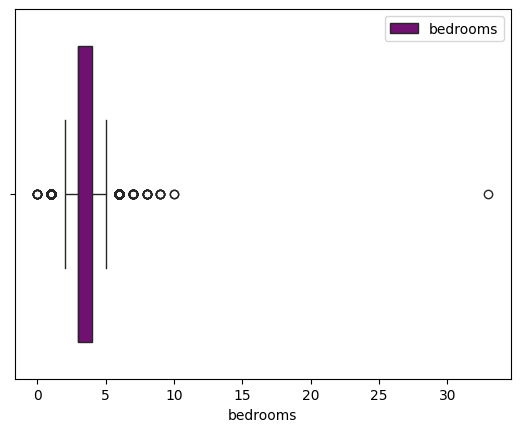

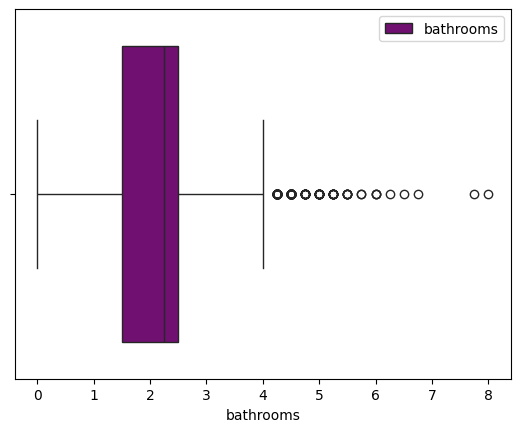

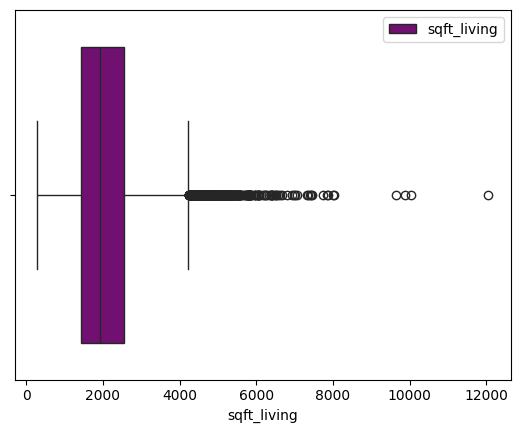

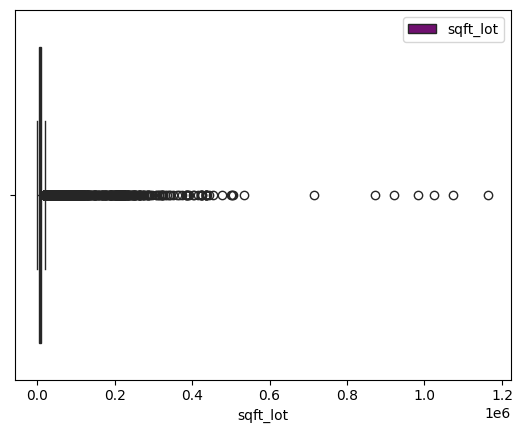

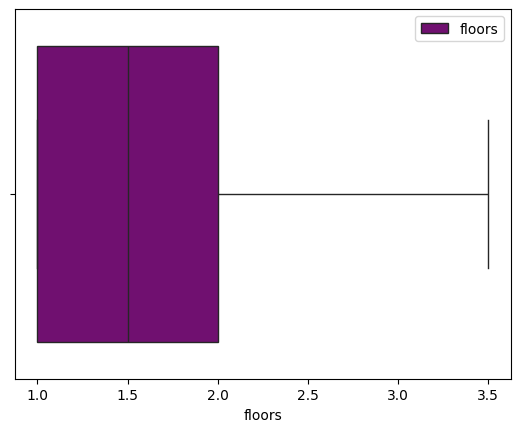

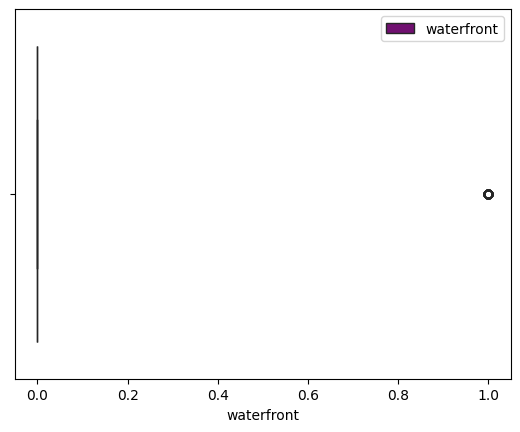

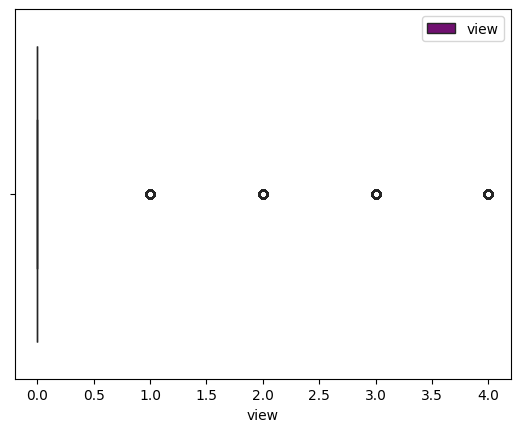

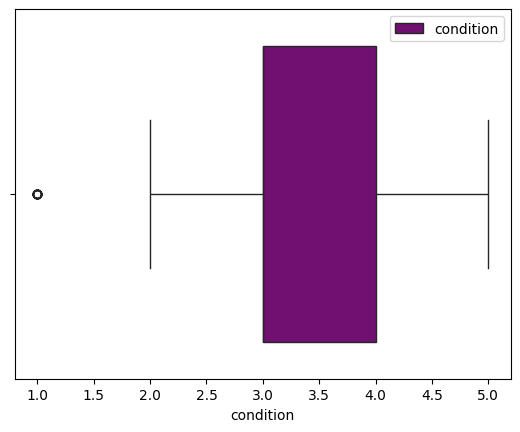

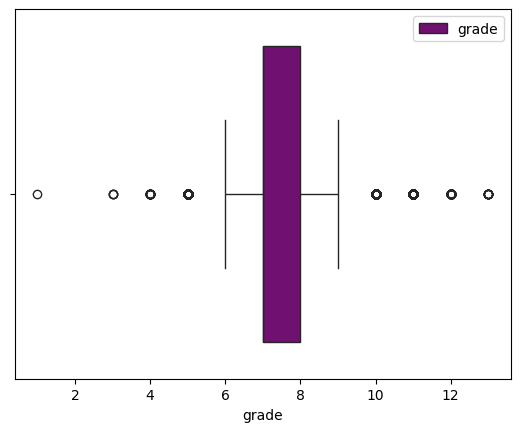

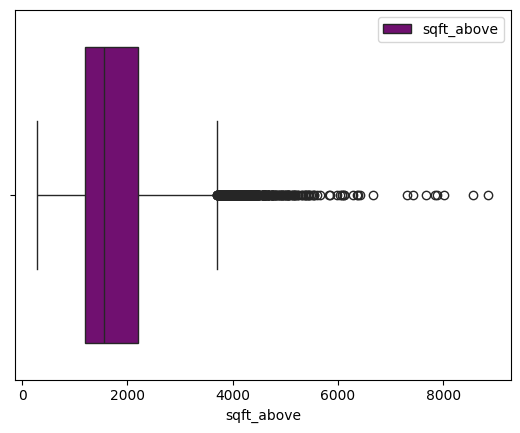

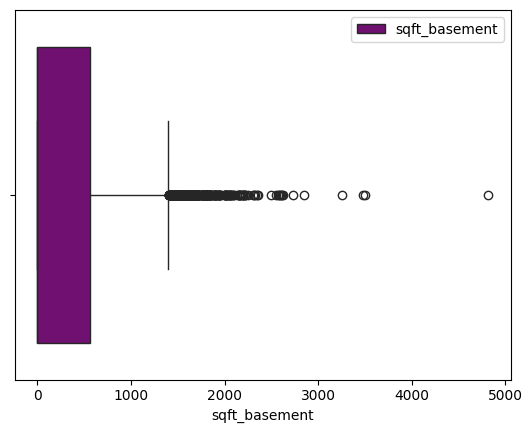

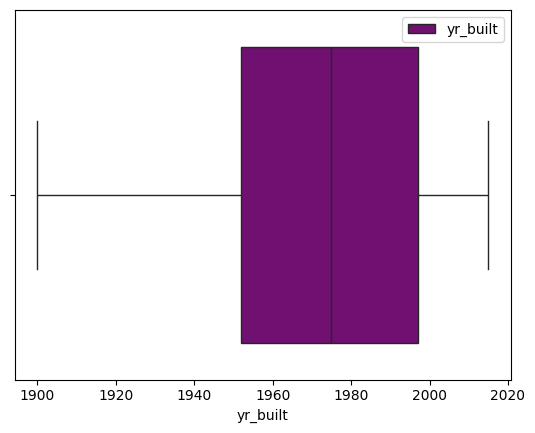

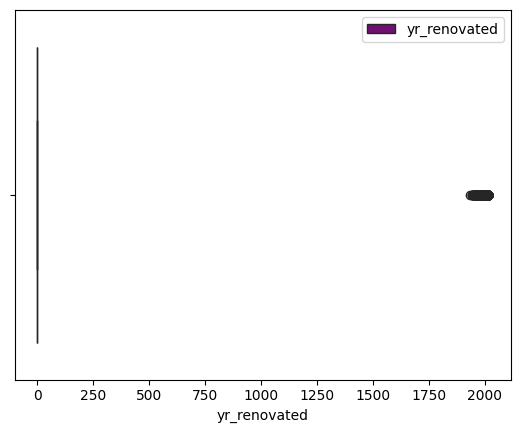

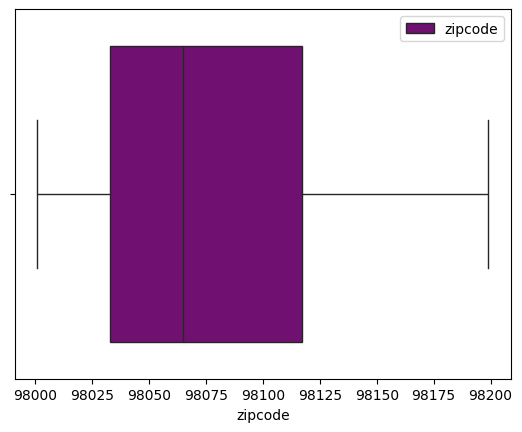

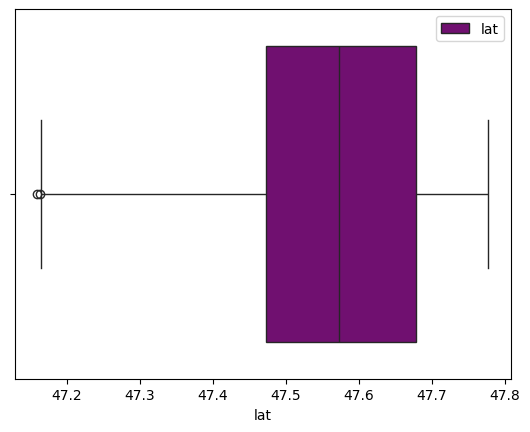

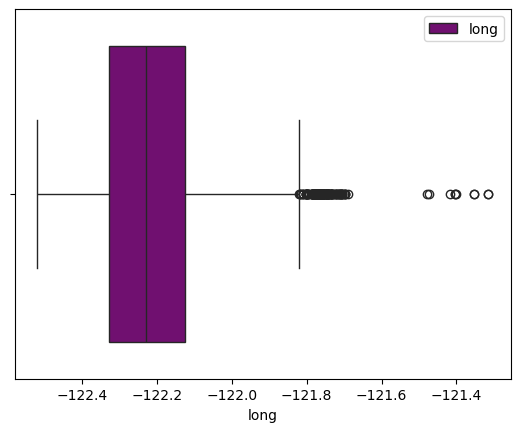

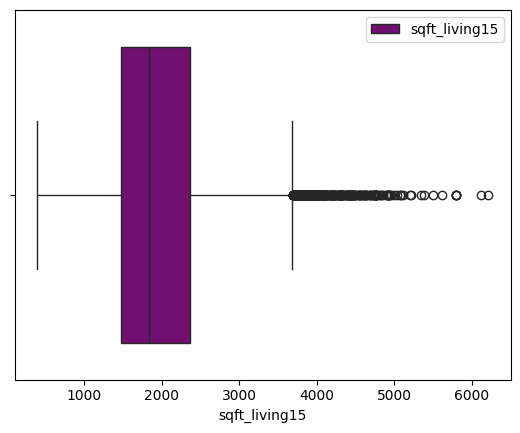

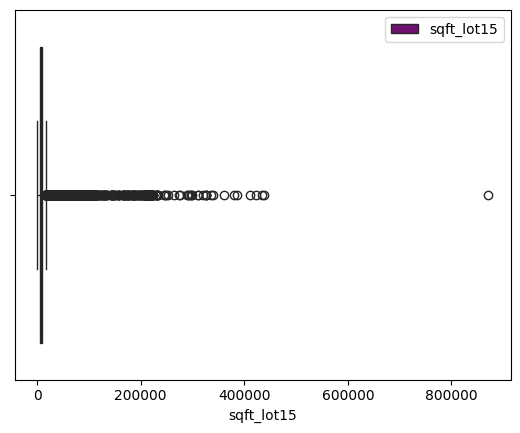

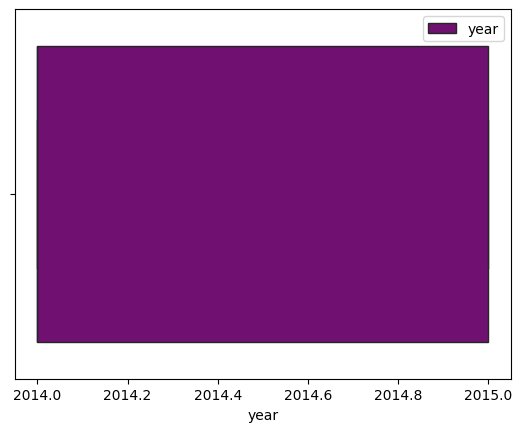

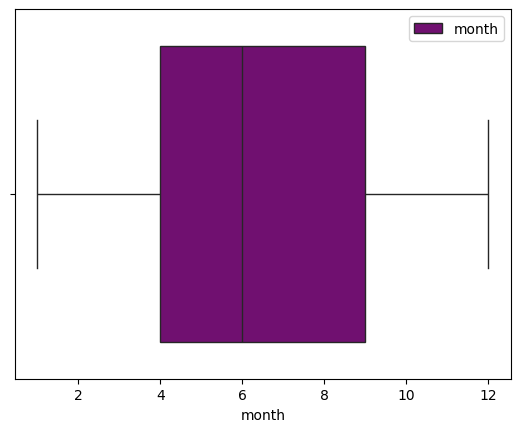

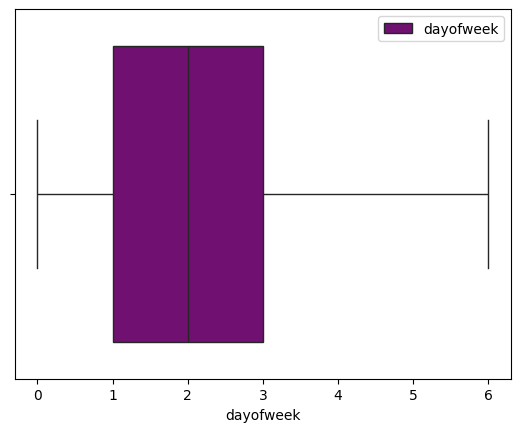

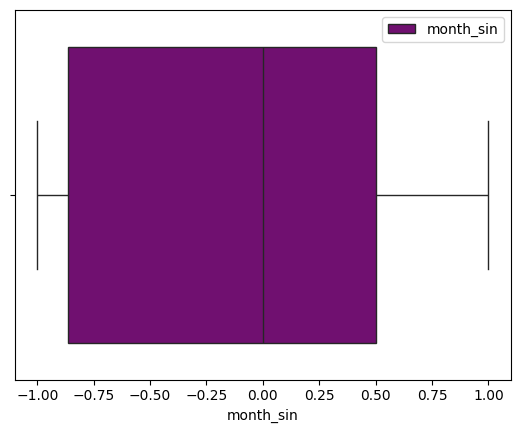

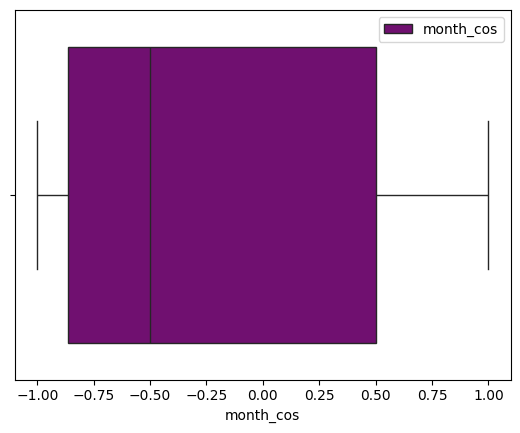

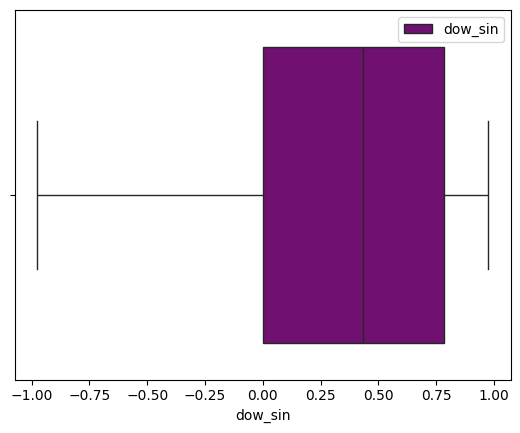

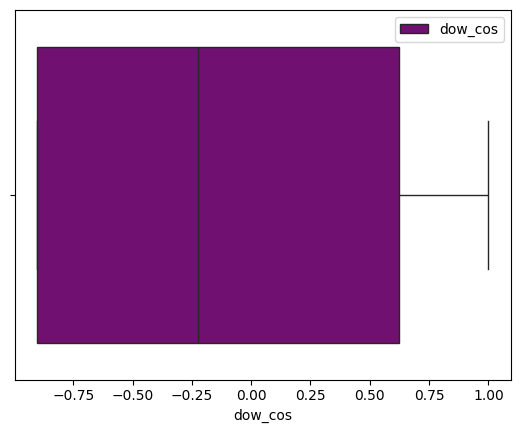

In [15]:
for i in X.columns :
  sns.boxplot(x =i ,data = X , label =i ,color ='purple')
  plt.legend()
  plt.show()

In [16]:
num_cols = ['bedrooms','bathrooms','waterfront','view','condition','grade','yr_renovated','sqft_basement']
X_num = X[num_cols]
X = X.drop(num_cols ,axis =1 )

In [17]:
X_num.head()

,bedrooms,bathrooms,waterfront,view,condition,grade,yr_renovated,sqft_basement
0,4,2.25,0,0,3,7,0,0
1,3,2.50,0,0,4,7,0,0
2,4,2.50,0,0,3,8,0,0
3,2,2.25,0,0,3,7,0,90
4,3,2.00,0,0,3,7,0,0


In [18]:
for i in X_num.columns :
  print(X_num[i].value_counts())
  print("--"*20)

bedrooms
3     7380
4     5128
2     2098
5     1213
6      197
1      142
7       26
8        9
0        8
9        5
10       2
33       1
Name: count, dtype: int64
----------------------------------------
bathrooms
2.50    4064
1.00    2891
1.75    2283
2.25    1532
2.00    1424
1.50    1094
2.75     913
3.00     547
3.50     544
3.25     441
3.75     109
4.00     104
4.50      75
4.25      59
0.75      51
5.00      17
4.75      16
5.25      11
1.25       8
0.00       7
5.50       6
0.50       3
6.00       3
5.75       2
6.25       1
7.75       1
8.00       1
6.75       1
6.50       1
Name: count, dtype: int64
----------------------------------------
waterfront
0    16096
1      113
Name: count, dtype: int64
----------------------------------------
view
0    14604
2      743
3      375
1      254
4      233
Name: count, dtype: int64
----------------------------------------
condition
3    10538
4     4238
5     1277
2      131
1       25
Name: count, dtype: int64
--------------------

In [19]:
n = 100
counts = X_num['yr_renovated'].value_counts()
infrequent_years = counts[counts < n].index.tolist()
X_num['yr_renovated'] = X_num['yr_renovated'].replace(infrequent_years, 'other')

In [20]:
X_num['yr_renovated'].value_counts()

,count
yr_renovated,
0,15537
other,672


In [21]:
threshold = 50
counts = X_num['bedrooms'].value_counts()
relp = counts[counts < threshold].index.tolist()
X_num['bedrooms'] = X_num['bedrooms'].replace(relp, 'other')

print(X_num['bedrooms'].value_counts())

bedrooms
3        7380
4        5128
2        2098
5        1213
6         197
1         142
other      51
Name: count, dtype: int64


In [22]:
threshold = 400
counts = X_num['bathrooms'].value_counts()
relp = counts[counts < threshold].index.tolist()
X_num['bathrooms'] = X_num['bathrooms'].replace(relp, 'other')

print(X_num['bathrooms'].value_counts())

bathrooms
2.5      4064
1.0      2891
1.75     2283
2.25     1532
2.0      1424
1.5      1094
2.75      913
3.0       547
3.5       544
other     476
3.25      441
Name: count, dtype: int64


In [23]:
threshold = 200
counts = X_num['grade'].value_counts()
relp = counts[counts < threshold].index.tolist()
X_num['grade'] = X_num['grade'].replace(relp, 'other')

print(X_num['grade'].value_counts())

grade
7        6761
8        4563
9        1943
6        1511
10        861
11        286
other     284
Name: count, dtype: int64


In [24]:
threshold = 130
counts = X_num['sqft_basement'].value_counts()
relp = counts[counts < threshold].index.tolist()
X_num['sqft_basement'] = X_num['sqft_basement'].replace(relp, 'other')

print(X_num['sqft_basement'].value_counts())

sqft_basement
0        9882
other    5540
600       177
700       162
800       159
500       155
400       134
Name: count, dtype: int64


In [25]:
X_num.head()

,bedrooms,bathrooms,waterfront,view,condition,grade,yr_renovated,sqft_basement
0,4,2.25,0,0,3,7,0,0
1,3,2.5,0,0,4,7,0,0
2,4,2.5,0,0,3,8,0,0
3,2,2.25,0,0,3,7,0,other
4,3,2.0,0,0,3,7,0,0


In [26]:
X_num = X_num.astype(str)

In [27]:
ohe = OneHotEncoder(sparse_output =False , dtype =np.int32)
X_num_new = ohe.fit_transform(X_num)
X_num_new = pd.DataFrame(X_num_new ,columns = ohe.get_feature_names_out(),index = X_num.index)

In [28]:
X_num_new.head()

,bedrooms_1,bedrooms_2,bedrooms_3,bedrooms_4,bedrooms_5,bedrooms_6,bedrooms_other,bathrooms_1.0,bathrooms_1.5,bathrooms_1.75,...,grade_other,yr_renovated_0,yr_renovated_other,sqft_basement_0,sqft_basement_400,sqft_basement_500,sqft_basement_600,sqft_basement_700,sqft_basement_800,sqft_basement_other
0,0,0,0,1,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
4,0,0,1,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0


In [29]:
no_out_cols = ['floors','yr_built','zipcode','lat','long']
no_out = X[no_out_cols]
X = X.drop(no_out_cols ,axis =1 )
X.head()

,sqft_living,sqft_lot,sqft_above,sqft_living15,sqft_lot15,year,month,dayofweek,month_sin,month_cos,dow_sin,dow_cos
0,1810,9240,1810,1660,9240,2015,5,1,5.000000e-01,-0.866025,0.781831,0.623490
1,1600,2788,1600,1720,3605,2014,7,1,-5.000000e-01,-0.866025,0.781831,0.623490
2,1720,8638,1720,1870,7455,2015,1,3,5.000000e-01,0.866025,0.433884,-0.900969
3,1240,705,1150,1240,750,2015,4,0,8.660254e-01,-0.500000,0.000000,1.000000
4,1280,13356,1280,1590,8071,2014,12,4,-2.449294e-16,1.000000,-0.433884,-0.900969


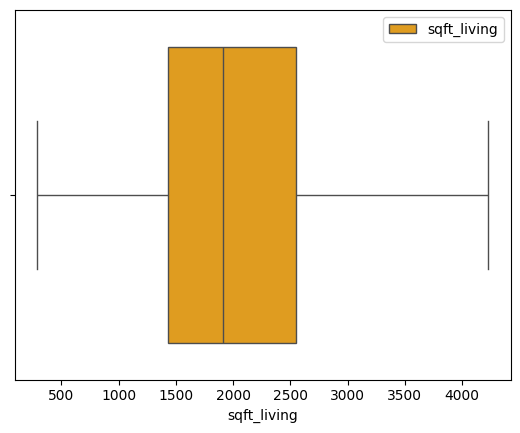

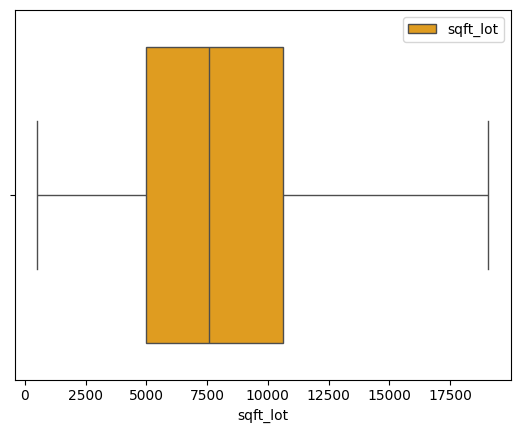

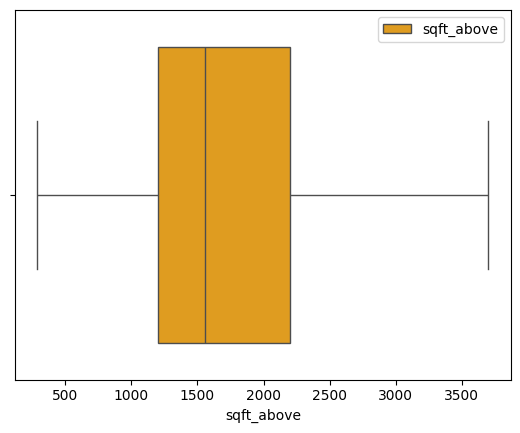

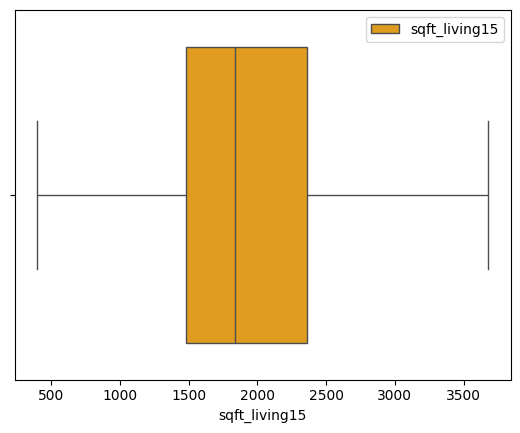

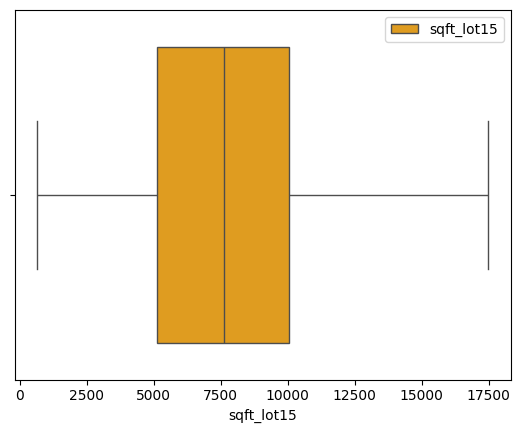

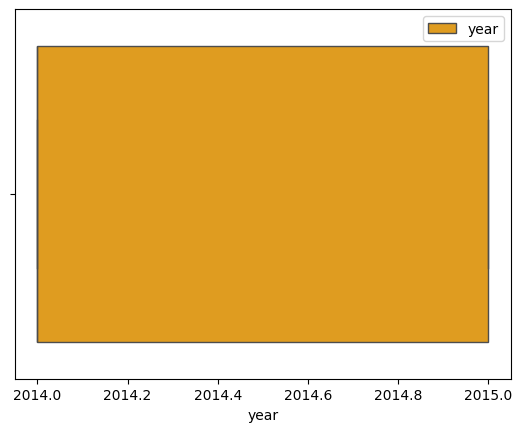

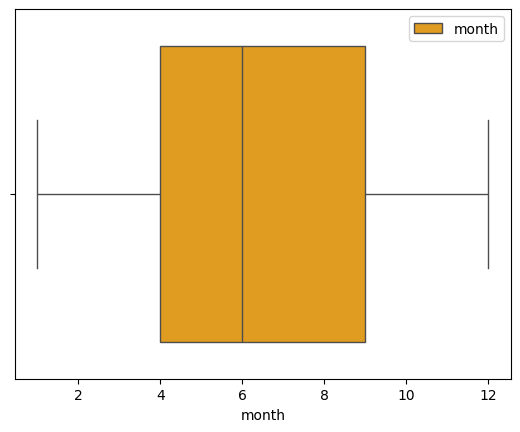

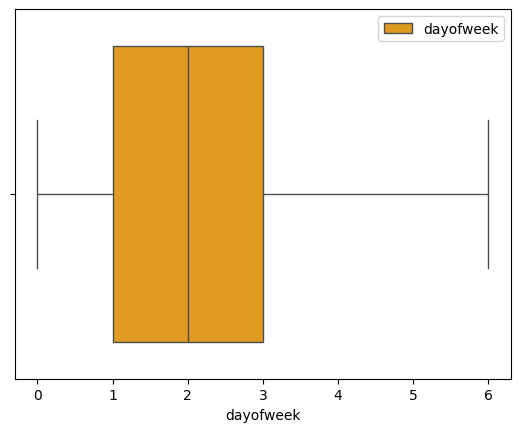

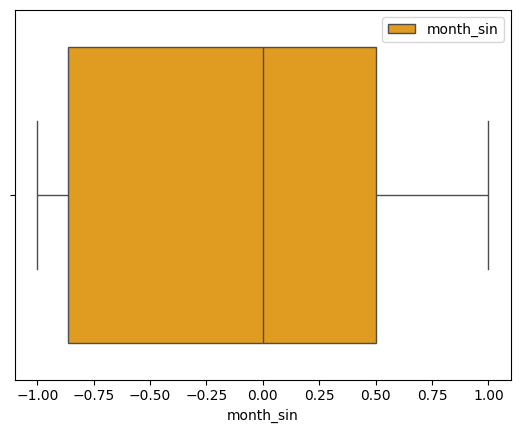

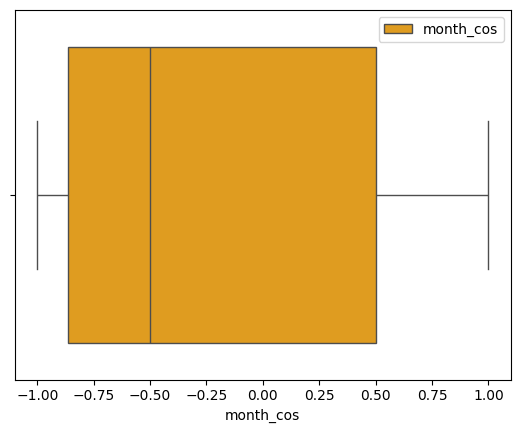

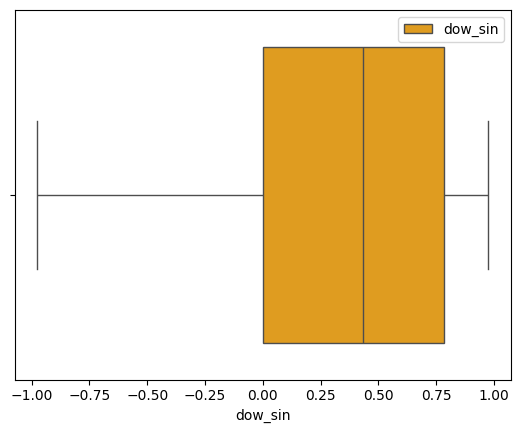

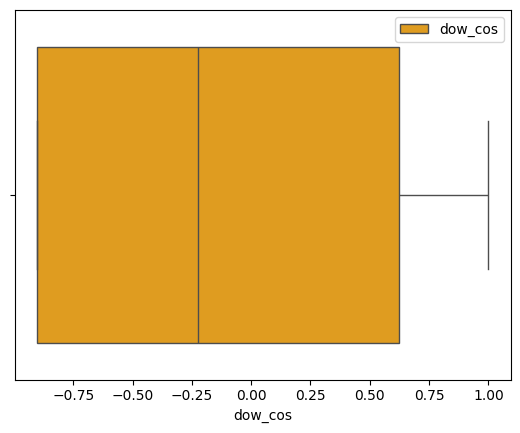

In [30]:
for i in X.columns :
  per25 = X[i].quantile(0.25)
  per75 = X[i].quantile(0.75)
  iqr = per75  -per25
  upper_lim = per75 + (1.5*iqr)
  lower_lim = per25 - (1.5*iqr)
  X[i] = np.where(X[i] > upper_lim ,upper_lim ,np.where(X[i] < lower_lim ,lower_lim ,X[i]))


for i in X.columns :
  sns.boxplot(x =i ,data = X , label =i ,color ='orange')
  plt.legend()
  plt.show()

In [31]:
trf = PowerTransformer(standardize = True)
X_new = trf.fit_transform(X)
X_new = pd.DataFrame(X_new ,columns = X.columns ,index = X.index)

In [32]:
X_new.skew()

,0
sqft_living,-0.010404
sqft_lot,-0.018263
sqft_above,0.010401
sqft_living15,0.004742
sqft_lot15,-0.010912
year,0.000000
month,-0.117976
dayofweek,-0.111174
month_sin,0.019791
month_cos,0.136131


In [33]:
no_out.skew()

,0
floors,0.615319
yr_built,-0.472681
zipcode,0.402986
lat,-0.488362
long,0.837556


In [34]:
no_out.iloc[:,0:3] = trf.fit_transform(no_out.iloc[:,0:3])

/tmp/ipython-input-3455399589.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.46373815  0.67589533  0.75991745 ...  1.20131827 -0.3987254
  1.29401194]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  no_out.iloc[:,0:3] = trf.fit_transform(no_out.iloc[:,0:3])
/tmp/ipython-input-3455399589.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-4.99600361e-15 -1.01585407e-14 -1.61537450e-14 ... -5.38458167e-15
  1.93178806e-14 -7.71605002e-15]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  no_out.iloc[:,0:3] = trf.fit_transform(no_out.iloc[:,0:3])


In [35]:
no_out.skew()

,0
floors,0.171849
yr_built,-0.089579
zipcode,0.000000
lat,-0.488362
long,0.837556


In [36]:
no_out.shape ,X_num_new.shape , X_new.shape

((16209, 5), (16209, 46), (16209, 12))

In [37]:
X_train_new = pd.concat([X_new , no_out ,X_num_new],axis =1 )

In [38]:
X_train_new.shape

(16209, 63)

In [39]:
X_train_new.head()

,sqft_living,sqft_lot,sqft_above,sqft_living15,sqft_lot15,year,month,dayofweek,month_sin,month_cos,...,grade_other,yr_renovated_0,yr_renovated_other,sqft_basement_0,sqft_basement_400,sqft_basement_500,sqft_basement_600,sqft_basement_700,sqft_basement_800,sqft_basement_other
0,-0.139769,0.294428,0.294591,-0.361812,0.367304,9.370282e-14,-0.458295,-0.608207,0.737048,-1.091924,...,0,1,0,1,0,0,0,0,0,0
1,-0.433294,-1.375272,-0.000730,-0.249912,-1.154831,-4.446443e-14,0.185216,-0.608207,-0.670457,-1.091924,...,0,1,0,1,0,0,0,0,0,0
2,-0.261929,0.178876,0.173030,0.011926,-0.036035,9.370282e-14,-1.955420,0.731580,0.737048,1.386374,...,0,1,0,1,0,0,0,0,0,0
3,-1.020288,-2.549131,-0.815256,-1.297395,-2.650780,9.370282e-14,-0.799579,-1.533034,1.234517,-0.445177,...,0,1,0,0,0,0,0,0,0,1
4,-0.948592,0.981847,-0.547268,-0.498164,0.108814,-4.446443e-14,1.643511,1.279816,0.043532,1.528466,...,0,1,0,1,0,0,0,0,0,0


In [40]:
train = pd.concat([X_train_new,y],axis =1 )
train.shape

(16209, 64)

# Test Data Preprocessing starts

In [ ]:
test.head()

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2591820310,20141006T000000,4,2.25,2070,8893,2.0,0,0,4,8,2070,0,1986,0,98058,47.4388,-122.162,2390,7700
1,7974200820,20140821T000000,5,3.00,2900,6730,1.0,0,0,5,8,1830,1070,1977,0,98115,47.6784,-122.285,2370,6283
2,7701450110,20140815T000000,4,2.50,3770,10893,2.0,0,2,3,11,3770,0,1997,0,98006,47.5646,-122.129,3710,9685
3,9522300010,20150331T000000,3,3.50,4560,14608,2.0,0,2,3,12,4560,0,1990,0,98034,47.6995,-122.228,4050,14226
4,9510861140,20140714T000000,3,2.50,2550,5376,2.0,0,0,3,9,2550,0,2004,0,98052,47.6647,-122.083,2250,4050


In [ ]:
test['date'] = pd.to_datetime(test['date'], format='%Y%m%dT%H%M%S')
test['year'] = test['date'].dt.year
test['month'] = test['date'].dt.month
test['day'] = test['date'].dt.day
test['dayofweek'] = test['date'].dt.dayofweek
test['quarter'] = test['date'].dt.quarter


In [ ]:
test = test.drop(columns=['quarter', 'day'])
test['month_sin'] = np.sin(2 * np.pi * test['month'] / 12)
test['month_cos'] = np.cos(2 * np.pi * test['month'] / 12)

test['dow_sin'] = np.sin(2 * np.pi * test['dayofweek'] / 7)
test['dow_cos'] = np.cos(2 * np.pi * test['dayofweek'] / 7)

test = test.drop(columns=['month', 'dayofweek'])

In [ ]:
test = test.drop('date',axis =1 )

In [ ]:
test_id = test['id']
test.head()
test = test.drop('id',axis =1 )

In [ ]:
test_num = test[num_cols]
test = test.drop(num_cols ,axis =1 )
test_num.head()

,bedrooms,bathrooms,waterfront,view,condition,grade,yr_renovated,sqft_basement
0,4,2.25,0,0,4,8,0,0
1,5,3.00,0,0,5,8,0,1070
2,4,2.50,0,2,3,11,0,0
3,3,3.50,0,2,3,12,0,0
4,3,2.50,0,0,3,9,0,0


In [ ]:
for i in test_num.columns :
  print(test_num[i].value_counts())
  print("--"*20)

bedrooms
3     2444
4     1754
2      662
5      388
6       75
1       57
7       12
0        5
8        4
11       1
9        1
10       1
Name: count, dtype: int64
----------------------------------------
bathrooms
2.50    1316
1.00     961
1.75     765
2.25     515
2.00     506
1.50     352
2.75     272
3.00     206
3.50     187
3.25     148
3.75      46
4.00      32
4.50      25
0.75      21
4.25      20
4.75       7
5.00       4
5.50       4
0.00       3
6.00       3
5.75       2
5.25       2
1.25       1
6.75       1
6.50       1
8.00       1
7.50       1
6.25       1
0.50       1
Name: count, dtype: int64
----------------------------------------
waterfront
0    5354
1      50
Name: count, dtype: int64
----------------------------------------
view
0    4885
2     220
3     135
4      86
1      78
Name: count, dtype: int64
----------------------------------------
condition
3    3493
4    1441
5     424
2      41
1       5
Name: count, dtype: int64
--------------------------------

In [ ]:
n = 30
counts = test_num['yr_renovated'].value_counts()
infrequent_years = counts[counts < n].index.tolist()
test_num['yr_renovated'] = test_num['yr_renovated'].replace(infrequent_years, 'other')
test_num['yr_renovated'].value_counts()

,count
yr_renovated,
0,5162
other,242


In [ ]:
threshold = 50
counts = test_num['bedrooms'].value_counts()
relp = counts[counts < threshold].index.tolist()
test_num['bedrooms'] = test_num['bedrooms'].replace(relp, 'other')

print(test_num['bedrooms'].value_counts())

bedrooms
3        2444
4        1754
2         662
5         388
6          75
1          57
other      24
Name: count, dtype: int64


In [ ]:
threshold = 100
counts = test_num['bathrooms'].value_counts()
relp = counts[counts < threshold].index.tolist()
test_num['bathrooms'] = test_num['bathrooms'].replace(relp, 'other')

print(test_num['bathrooms'].value_counts())

bathrooms
2.5      1316
1.0       961
1.75      765
2.25      515
2.0       506
1.5       352
2.75      272
3.0       206
3.5       187
other     176
3.25      148
Name: count, dtype: int64


In [ ]:
threshold = 100
counts = test_num['grade'].value_counts()
relp = counts[counts < threshold].index.tolist()
test_num['grade'] = test_num['grade'].replace(relp, 'other')

print(test_num['grade'].value_counts())

grade
7        2220
8        1505
9         672
6         527
10        273
11        113
other      94
Name: count, dtype: int64


In [ ]:
threshold = 40
counts = test_num['sqft_basement'].value_counts()
relp = counts[counts < threshold].index.tolist()
test_num['sqft_basement'] = test_num['sqft_basement'].replace(relp, 'other')

print(test_num['sqft_basement'].value_counts())

sqft_basement
0        3244
other    1904
500        59
700        56
400        50
800        47
600        44
Name: count, dtype: int64


In [ ]:
test_num = test_num.astype(str)
ohe = OneHotEncoder(sparse_output =False , dtype =np.int32)
test_num_new = ohe.fit_transform(test_num)
test_num_new = pd.DataFrame(test_num_new ,columns = ohe.get_feature_names_out(),index = test_num.index)

In [ ]:
no_out_cols = ['floors','yr_built','zipcode','lat','long']
no_out = test[no_out_cols]
test = test.drop(no_out_cols ,axis =1 )
test.head()

,sqft_living,sqft_lot,sqft_above,sqft_living15,sqft_lot15,year,month_sin,month_cos,dow_sin,dow_cos
0,2070,8893,2070,2390,7700,2014,-0.866025,5.000000e-01,0.000000,1.000000
1,2900,6730,1830,2370,6283,2014,-0.866025,-5.000000e-01,0.433884,-0.900969
2,3770,10893,3770,3710,9685,2014,-0.866025,-5.000000e-01,-0.433884,-0.900969
3,4560,14608,4560,4050,14226,2015,1.000000,6.123234e-17,0.781831,0.623490
4,2550,5376,2550,2250,4050,2014,-0.500000,-8.660254e-01,0.000000,1.000000


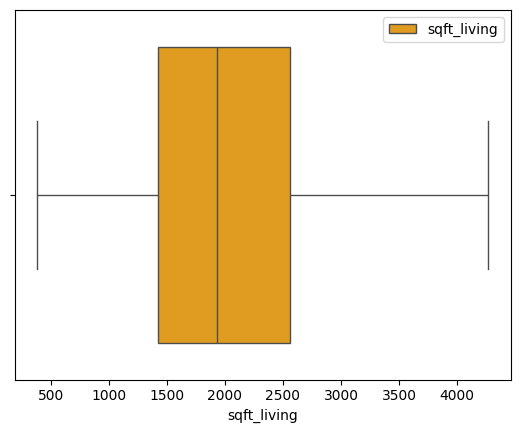

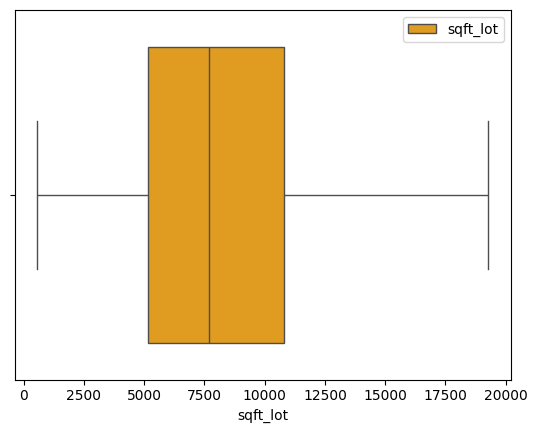

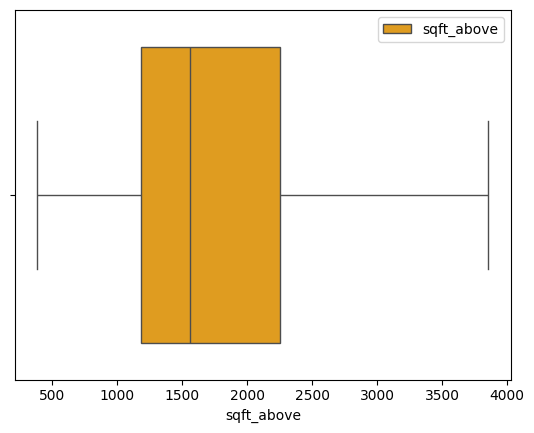

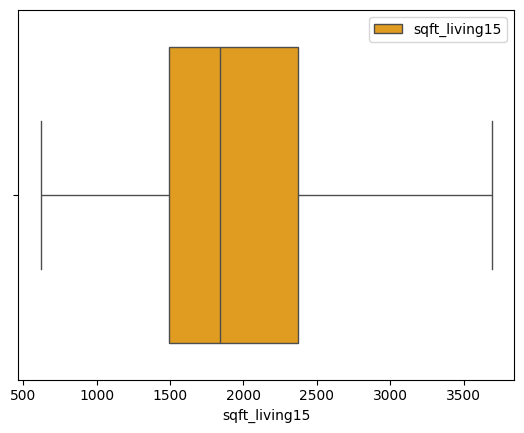

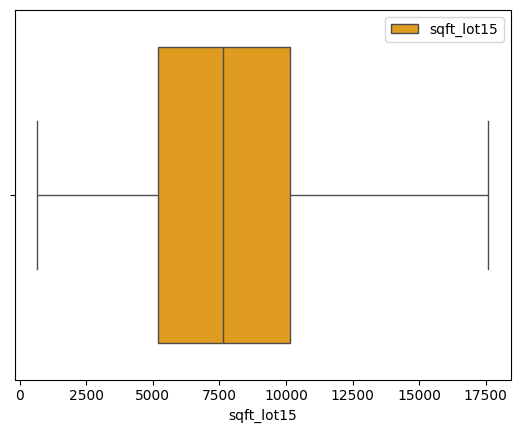

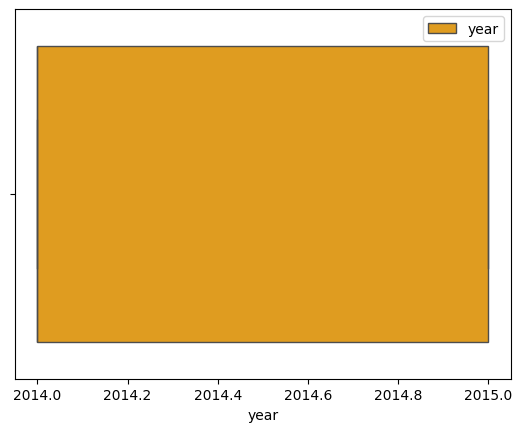

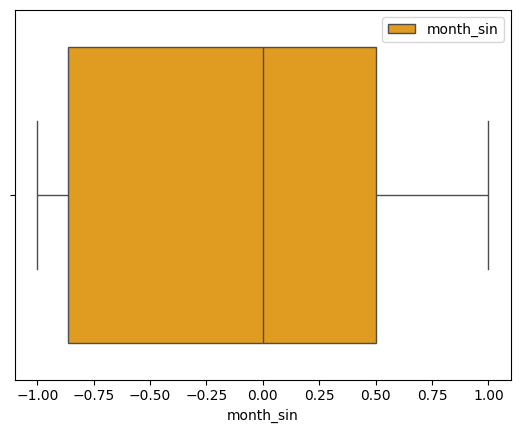

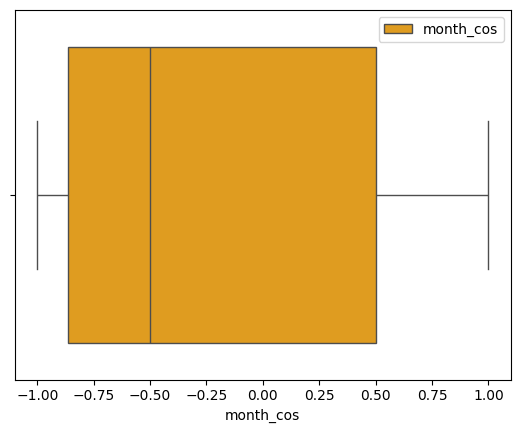

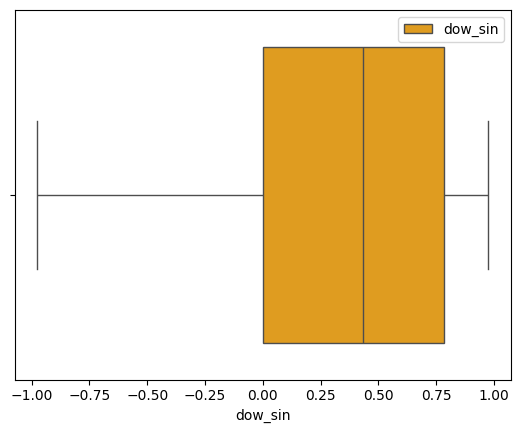

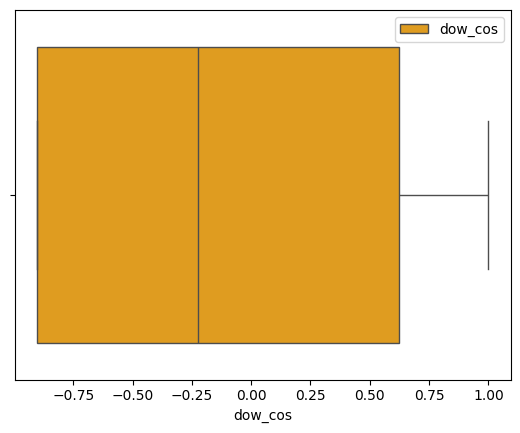

In [ ]:
for i in test.columns:
  per25 = test[i].quantile(0.25)
  per75 = test[i].quantile(0.75)
  iqr = per75  -per25
  upper_lim = per75 + (1.5*iqr)
  lower_lim = per25 - (1.5*iqr)
  test[i] = np.where(test[i] > upper_lim ,upper_lim ,np.where(test[i] < lower_lim ,lower_lim ,test[i]))


for i in test.columns :
  sns.boxplot(x =i ,data = test , label =i ,color ='orange')
  plt.legend()
  plt.show()

In [ ]:
trf = PowerTransformer(standardize = True)
test_new = trf.fit_transform(test)
test_new = pd.DataFrame(test_new ,columns = test.columns ,index = test.index)

In [ ]:
test_new.skew() ,test.skew()

(sqft_living     -0.010437
 sqft_lot        -0.013515
 sqft_above       0.012999
 sqft_living15    0.009091
 sqft_lot15      -0.009375
 year             0.000000
 month_sin        0.008564
 month_cos        0.143541
 dow_sin         -0.215987
 dow_cos          0.055840
 dtype: float64,
 sqft_living      0.736536
 sqft_lot         0.839228
 sqft_above       0.926531
 sqft_living15    0.794323
 sqft_lot15       0.768096
 year             0.743243
 month_sin        0.022214
 month_cos        0.329906
 dow_sin         -0.488931
 dow_cos          0.118075
 dtype: float64)

In [ ]:
no_out.iloc[:,0:3] = trf.fit_transform(no_out.iloc[:,0:3])

/tmp/ipython-input-3455399589.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.45701838  0.11270353  0.91294558 ...  0.18708355 -1.66205608
 -0.30927575]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  no_out.iloc[:,0:3] = trf.fit_transform(no_out.iloc[:,0:3])
/tmp/ipython-input-3455399589.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-4.27435864e-15  8.04911693e-15 -1.54876112e-14 ... -1.17683641e-14
  7.43849426e-15 -4.88498131e-15]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  no_out.iloc[:,0:3] = trf.fit_transform(no_out.iloc[:,0:3])


In [ ]:
no_out.shape ,test_num_new.shape , test_new.shape

((5404, 5), (5404, 46), (5404, 10))

In [ ]:
test_new = pd.concat([test_id ,test_new , no_out ,test_num_new],axis =1 )

In [ ]:
test_new.shape

(5404, 62)

In [ ]:
test_new.head()

,id,sqft_living,sqft_lot,sqft_above,sqft_living15,sqft_lot15,year,month_sin,month_cos,dow_sin,...,grade_other,yr_renovated_0,yr_renovated_other,sqft_basement_0,sqft_basement_400,sqft_basement_500,sqft_basement_600,sqft_basement_700,sqft_basement_800,sqft_basement_other
0,2591820310,0.166806,0.199326,0.591864,0.755685,-0.000315,-4.463097e-14,-1.224746,0.974179,-0.769838,...,0,1,0,1,0,0,0,0,0,0
1,7974200820,1.009472,-0.254074,0.308057,0.730493,-0.353140,-4.463097e-14,-1.224746,-0.435512,0.021347,...,0,1,0,0,0,0,0,0,0,1
2,7701450110,1.697622,0.559292,1.899235,2.009726,0.435429,-4.463097e-14,-1.224746,-0.435512,-1.387319,...,0,1,0,1,0,0,0,0,0,0
3,9522300010,2.034593,1.129022,1.945594,2.009726,1.266848,9.242607e-14,1.413556,0.337955,0.782134,...,1,1,0,1,0,0,0,0,0,0
4,9510861140,0.682605,-0.587696,1.060206,0.573921,-1.019664,-4.463097e-14,-0.697348,-1.083843,-0.769838,...,0,1,0,1,0,0,0,0,0,0


In [41]:
train.to_csv('train_new.csv')

In [ ]:
test_new.to_csv('test_new.csv')